<a href="https://colab.research.google.com/github/Sakti-Cristopel/Dasar-Python/blob/main/Pertemuan%2011_Sakti%20Cristopel%20Lingga_240401010125.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 11 — Unsupervised Learning: Clustering

Nama Lengkap: Sakti Cristopel Lingga

NIM: 2404010125

Kelas: IF403

Topik:
K-Means, Elbow Method, Silhouette Score, dan Hierarchical Clustering

Dataset:
Dataset Sintetis Segmentasi Pelanggan

## Deskripsi Tugas

Clustering merupakan salah satu metode Unsupervised Learning yang digunakan untuk mengelompokkan data berdasarkan kemiripan karakteristik tanpa menggunakan label atau target yang telah ditentukan sebelumnya.

Pada praktikum ini digunakan dataset pelanggan sintetis yang memiliki fitur pendapatan tahunan, skor belanja, usia, dan gender. Dataset dibuat untuk merepresentasikan tiga kelompok pelanggan tersembunyi, yaitu pelanggan hemat, pelanggan menengah, dan pelanggan dengan tingkat belanja tinggi.

Metode K-Means digunakan untuk melakukan segmentasi pelanggan. Metode Elbow digunakan untuk menentukan jumlah cluster yang optimal, sedangkan Silhouette Score digunakan untuk mengevaluasi kualitas hasil clustering. Hierarchical Clustering kemudian digunakan sebagai metode pembanding.

## Tujuan Praktikum

Praktikum ini bertujuan untuk:

1. Memahami konsep Unsupervised Learning dan Clustering.
2. Membuat dataset sintetis untuk segmentasi pelanggan.
3. Melakukan eksplorasi data menggunakan statistik deskriptif dan visualisasi.
4. Melakukan StandardScaler pada fitur numerik.
5. Menentukan jumlah cluster optimal menggunakan Elbow Method.
6. Membangun model K-Means Clustering.
7. Mengevaluasi hasil clustering menggunakan WCSS dan Silhouette Score.
8. Menginterpretasikan karakteristik setiap cluster.
9. Membandingkan K-Means dengan Hierarchical Clustering.

In [18]:
# Import library untuk pengolahan data
import numpy as np
import pandas as pd

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing
from sklearn.preprocessing import StandardScaler

# Import algoritma K-Means
from sklearn.cluster import KMeans

# Import metrik evaluasi clustering
from sklearn.metrics import silhouette_score

# Import Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## Langkah 1 — Generate dan Eksplorasi Dataset

Dataset pelanggan dibuat secara sintetis menggunakan distribusi normal. Dataset terdiri dari tiga kelompok tersembunyi dengan karakteristik pendapatan dan skor belanja yang berbeda.

Kelompok pertama merepresentasikan pelanggan hemat, kelompok kedua pelanggan dengan tingkat pendapatan dan belanja menengah, sedangkan kelompok ketiga merepresentasikan pelanggan dengan pendapatan dan tingkat belanja tinggi.

Setiap kelompok terdiri dari 100 pelanggan sehingga jumlah keseluruhan dataset adalah 300 pelanggan.

In [19]:
# Menentukan seed agar hasil dapat direproduksi
np.random.seed(42)

# Kelompok 1: pelanggan hemat
grp1 = np.random.normal(
    [30, 20],
    [6, 8],
    (100, 2)
)

# Kelompok 2: pelanggan menengah
grp2 = np.random.normal(
    [70, 55],
    [8, 10],
    (100, 2)
)

# Kelompok 3: pelanggan boros/premium
grp3 = np.random.normal(
    [110, 85],
    [10, 8],
    (100, 2)
)

# Menggabungkan ketiga kelompok
data = np.vstack([
    grp1,
    grp2,
    grp3
])

# Membuat DataFrame
df = pd.DataFrame(
    data,
    columns=[
        "pendapatan_tahunan",
        "skor_belanja"
    ]
)

# Menambahkan usia
df["usia"] = np.random.randint(
    18,
    65,
    len(df)
)

# Menambahkan gender
df["gender"] = np.random.choice(
    ["L", "P"],
    len(df)
)

print("Dataset berhasil dibuat.")
print("Shape:", df.shape)

Dataset berhasil dibuat.
Shape: (300, 4)


In [20]:
# Menampilkan lima data pertama

display(df.head())

# Statistik deskriptif

print("Statistik Deskriptif:")
display(df.describe().round(2))

,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


Statistik Deskriptif:


,pendapatan_tahunan,skor_belanja,usia
count,300.00,300.00,300.00
mean,69.96,53.23,42.07
std,33.82,27.41,13.59
min,14.28,4.10,18.00
25%,32.14,25.60,30.00
50%,70.84,55.11,43.00
75%,103.40,78.16,53.00
max,140.79,103.17,64.00


## Interpretasi Awal

Dataset terdiri dari 300 pelanggan dan 4 atribut, yaitu pendapatan tahunan, skor belanja, usia, dan gender.

Pendapatan tahunan dan skor belanja menjadi fitur utama yang digunakan untuk clustering. Usia dan gender tetap terdapat pada dataset, tetapi tidak digunakan dalam proses K-Means karena praktikum berfokus pada segmentasi berdasarkan pendapatan dan perilaku belanja.

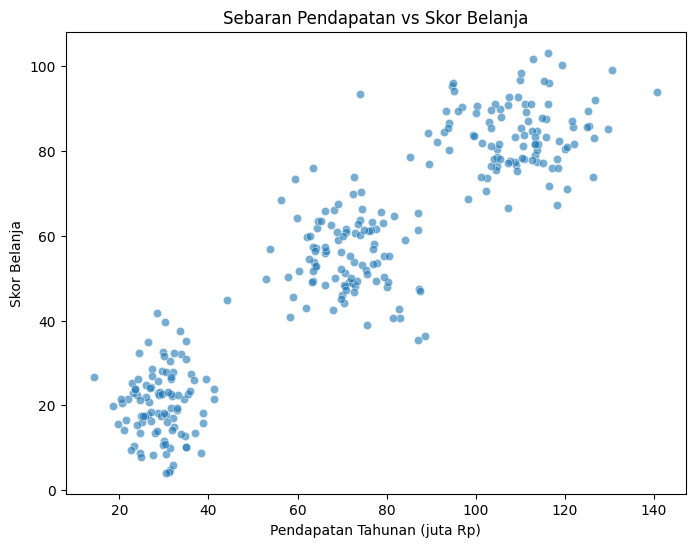

In [21]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja",
    alpha=0.6
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")

plt.show()

## Interpretasi Visualisasi

Scatter plot menunjukkan adanya tiga kelompok data yang terlihat berdasarkan kombinasi pendapatan tahunan dan skor belanja. Kelompok pertama berada pada area pendapatan dan skor belanja rendah, kelompok kedua berada pada area menengah, sedangkan kelompok ketiga berada pada area pendapatan dan skor belanja tinggi.

Pola tersebut menjadi indikasi awal bahwa dataset dapat dikelompokkan menjadi sekitar tiga cluster.

## Langkah 2 — Preprocessing Data

K-Means menggunakan jarak untuk menentukan kedekatan antar data. Oleh karena itu, fitur yang memiliki skala lebih besar dapat memberikan pengaruh yang lebih besar terhadap pembentukan cluster.

StandardScaler digunakan untuk mengubah setiap fitur sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1.

Pada praktikum ini fitur yang digunakan adalah pendapatan tahunan dan skor belanja.

In [22]:
# Memilih fitur yang digunakan untuk clustering

X = df[
    [
        "pendapatan_tahunan",
        "skor_belanja"
    ]
].values

# Membuat StandardScaler

scaler = StandardScaler()

# Melakukan scaling

X_scaled = scaler.fit_transform(X)

print(
    "Rata-rata setelah scaling:",
    X_scaled.mean(axis=0).round(3)
)

print(
    "Std setelah scaling:",
    X_scaled.std(axis=0).round(3)
)

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling: [1. 1.]


## Langkah 3 — Menentukan Jumlah Cluster dengan Elbow Method

Elbow Method digunakan untuk menentukan jumlah cluster yang sesuai. Metode ini menghitung WCSS atau Within-Cluster Sum of Squares untuk beberapa nilai K.

WCSS menunjukkan total jarak kuadrat antara data dengan centroid cluster-nya. Semakin banyak cluster yang digunakan, WCSS biasanya semakin kecil. Namun, penggunaan terlalu banyak cluster tidak selalu diperlukan.

Jumlah cluster yang optimal dapat diperkirakan dari titik ketika penurunan WCSS mulai melandai. Titik tersebut disebut sebagai elbow atau siku.

In [23]:
wcss = []

for k in range(1, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++",
        n_init=10
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

print("Nilai WCSS:")

for k, value in enumerate(wcss, start=1):
    print(f"K={k}: {value:.3f}")

Nilai WCSS:
K=1: 600.000
K=2: 161.732
K=3: 44.556
K=4: 37.885
K=5: 31.445
K=6: 26.203
K=7: 21.564
K=8: 18.961
K=9: 17.390
K=10: 16.013


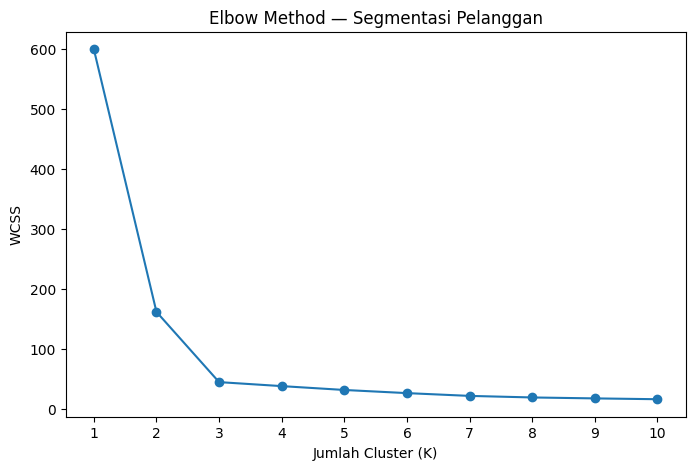

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method — Segmentasi Pelanggan")

plt.xticks(range(1, 11))

plt.show()

## Interpretasi Elbow Method

Berdasarkan grafik Elbow Method, penurunan nilai WCSS terlihat sangat besar dari K=1 menuju K=2 dan masih mengalami penurunan ketika K=3. Setelah K=3, penurunan WCSS mulai lebih kecil dan kurva cenderung melandai.

Dengan demikian, K=3 dapat dipilih sebagai jumlah cluster yang optimal. Hasil tersebut juga sesuai dengan struktur dataset sintetis yang sejak awal dibuat dengan tiga kelompok pelanggan tersembunyi.

## Langkah 4 — Melatih Model K-Means

Berdasarkan hasil Elbow Method, jumlah cluster yang dipilih adalah K=3.

Model K-Means kemudian dilatih menggunakan data yang telah distandarisasi. Setelah proses training selesai, setiap pelanggan akan mendapatkan label cluster dari 0 sampai 2.

In [25]:
# Membuat model K-Means dengan 3 cluster

model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++",
    n_init=10
)

# Melatih model

model.fit(X_scaled)

# Menambahkan label cluster ke dataset

df["cluster"] = model.labels_

print("K-Means berhasil dilatih.")

K-Means berhasil dilatih.


In [26]:
# Menghitung WCSS akhir

print(
    f"WCSS akhir: {model.inertia_:.3f}"
)

# Menghitung Silhouette Score

sil_score = silhouette_score(
    X_scaled,
    model.labels_
)

print(
    f"Silhouette Score: {sil_score:.3f}"
)

# Rata-rata karakteristik setiap cluster

cluster_summary = df.groupby(
    "cluster"
)[
    [
        "pendapatan_tahunan",
        "skor_belanja"
    ]
].mean().round(2)

print("Rata-rata setiap cluster:")

display(cluster_summary)

WCSS akhir: 44.556
Silhouette Score: 0.695
Rata-rata setiap cluster:


,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


## Interpretasi Evaluasi

WCSS menunjukkan tingkat kedekatan data terhadap centroid cluster. Nilai WCSS yang lebih kecil menunjukkan data berada lebih dekat dengan centroid masing-masing cluster.

Silhouette Score digunakan untuk mengukur seberapa baik data berada dalam cluster-nya dibandingkan dengan cluster lain. Nilai yang semakin mendekati 1 menunjukkan pemisahan cluster yang semakin baik.

Tabel rata-rata setiap cluster digunakan untuk memahami karakteristik pelanggan berdasarkan pendapatan tahunan dan skor belanja.

In [27]:
# Melihat pusat rata-rata masing-masing cluster

display(
    cluster_summary
)

,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


## Langkah 5 — Visualisasi Hasil Clustering

Hasil K-Means divisualisasikan menggunakan scatter plot. Setiap warna menunjukkan cluster yang berbeda, sedangkan tanda X menunjukkan posisi centroid masing-masing cluster.

Visualisasi ini digunakan untuk melihat apakah hasil pengelompokan K-Means sesuai dengan pola data yang terlihat pada tahap eksplorasi.

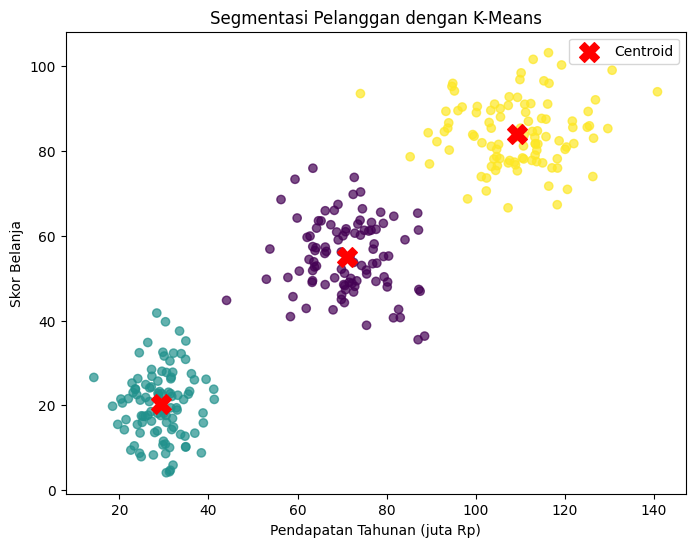

In [28]:
# Mengembalikan centroid ke skala asli

centroids = scaler.inverse_transform(
    model.cluster_centers_
)

plt.figure(figsize=(8, 6))

# Visualisasi data berdasarkan cluster

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

# Visualisasi centroid

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroid"
)

plt.xlabel(
    "Pendapatan Tahunan (juta Rp)"
)

plt.ylabel(
    "Skor Belanja"
)

plt.title(
    "Segmentasi Pelanggan dengan K-Means"
)

plt.legend()

plt.show()

## Interpretasi Hasil Clustering

Hasil clustering menunjukkan bahwa pelanggan dapat dikelompokkan menjadi tiga segmen berdasarkan pendapatan tahunan dan skor belanja.

Segmen dengan pendapatan dan skor belanja rendah dapat dikategorikan sebagai pelanggan hemat. Segmen dengan nilai pendapatan dan skor belanja menengah dapat dikategorikan sebagai pelanggan menengah. Sementara itu, segmen dengan pendapatan dan skor belanja tinggi dapat dikategorikan sebagai pelanggan premium atau pelanggan dengan tingkat belanja tinggi.

Segmentasi ini dapat membantu perusahaan menentukan strategi pemasaran yang berbeda untuk setiap kelompok pelanggan.

## Langkah 6 — Hierarchical Clustering

Hierarchical Clustering digunakan sebagai metode pembanding terhadap K-Means. Metode ini membangun struktur hierarki antar data berdasarkan jarak.

Pada praktikum ini digunakan Ward Linkage. Dendrogram digunakan untuk melihat bagaimana data bergabung menjadi kelompok pada berbagai tingkat jarak.

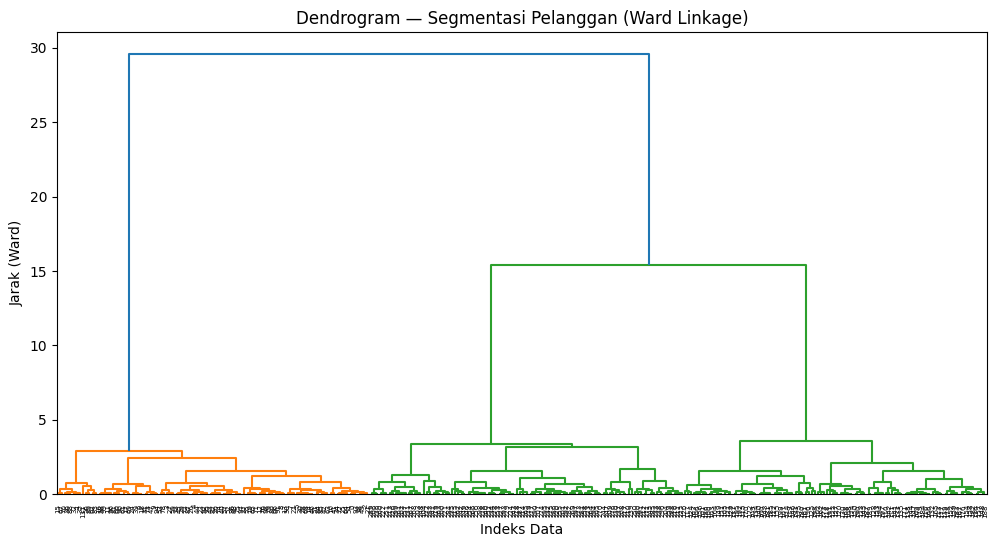

In [29]:
# Membuat hierarchical clustering menggunakan Ward linkage

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    Z
)

plt.title(
    "Dendrogram — Segmentasi Pelanggan (Ward Linkage)"
)

plt.xlabel(
    "Indeks Data"
)

plt.ylabel(
    "Jarak (Ward)"
)

plt.show()

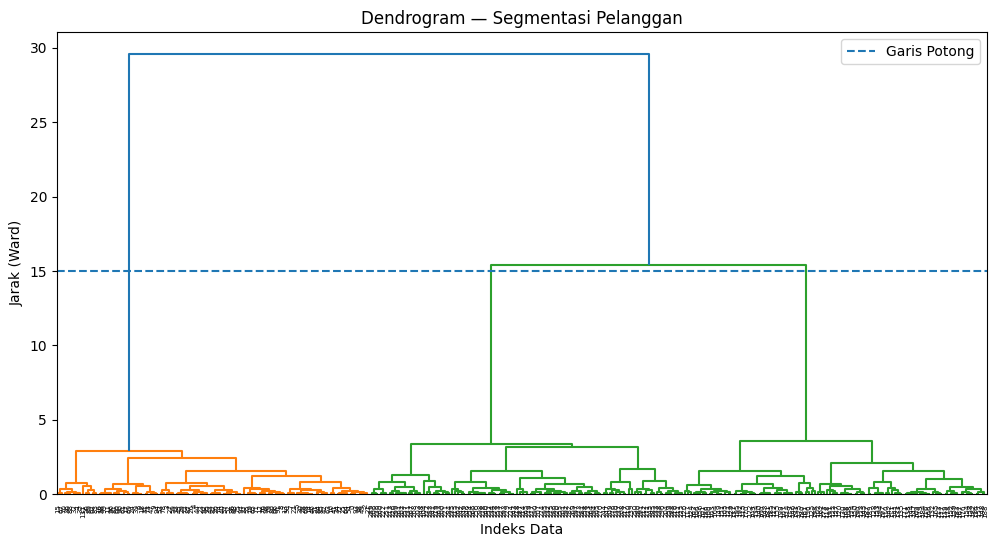

In [30]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z
)

plt.axhline(
    y=15,
    linestyle="--",
    label="Garis Potong"
)

plt.title(
    "Dendrogram — Segmentasi Pelanggan"
)

plt.xlabel(
    "Indeks Data"
)

plt.ylabel(
    "Jarak (Ward)"
)

plt.legend()

plt.show()

## Interpretasi Hierarchical Clustering

Dendrogram menunjukkan proses penggabungan data secara bertahap berdasarkan jarak. Dengan memilih garis potong pada tingkat jarak tertentu, jumlah kelompok dapat diperkirakan dari banyaknya cabang utama yang dipotong.

Hasil Hierarchical Clustering dapat dibandingkan dengan K-Means. Jika garis potong menghasilkan sekitar tiga kelompok utama, maka hasil tersebut konsisten dengan Elbow Method yang memilih K=3.

Konsistensi tersebut menunjukkan bahwa struktur tiga segmen pelanggan pada dataset cukup jelas.

## Perbandingan Metode

K-Means menentukan jumlah cluster terlebih dahulu dan kemudian mencari centroid yang meminimalkan jarak data terhadap pusat cluster. Metode ini relatif cepat dan sesuai digunakan ketika jumlah cluster telah diketahui atau dapat diperkirakan.

Hierarchical Clustering membentuk struktur hierarki antar data sehingga hubungan antar kelompok dapat diamati melalui dendrogram. Kelebihannya adalah jumlah cluster tidak harus ditentukan sejak awal, tetapi metode ini dapat menjadi lebih berat ketika jumlah data sangat besar.

Pada dataset ini, kedua metode digunakan untuk memastikan apakah struktur tiga kelompok pelanggan yang terlihat pada K-Means juga didukung oleh pendekatan hierarchical clustering.

## Ringkasan Hasil Praktikum

Berdasarkan seluruh proses yang dilakukan:

- Dataset terdiri dari 300 pelanggan.
- Fitur utama yang digunakan adalah pendapatan tahunan dan skor belanja.
- StandardScaler digunakan agar kedua fitur memiliki skala yang setara.
- Elbow Method digunakan untuk menentukan jumlah cluster optimal.
- Hasil pengamatan menunjukkan K=3 sebagai jumlah cluster yang sesuai.
- K-Means digunakan untuk membentuk tiga segmen pelanggan.
- Silhouette Score digunakan untuk mengevaluasi kualitas pemisahan cluster.
- Hasil clustering menunjukkan adanya kelompok pelanggan dengan karakteristik hemat, menengah, dan premium/boros.
- Hierarchical Clustering digunakan sebagai metode pembanding dan divisualisasikan menggunakan dendrogram.

# Kesimpulan

Pada praktikum ini telah dipelajari penerapan Unsupervised Learning menggunakan metode K-Means dan Hierarchical Clustering untuk melakukan segmentasi pelanggan. Dataset sintetis yang digunakan memiliki tiga kelompok pelanggan berdasarkan pendapatan tahunan dan skor belanja. StandardScaler digunakan untuk menyamakan skala fitur, sedangkan Elbow Method digunakan untuk menentukan jumlah cluster yang optimal dan menghasilkan K=3. Hasil K-Means menunjukkan tiga segmen pelanggan yang dapat diinterpretasikan sebagai pelanggan hemat, menengah, dan premium/boros berdasarkan rata-rata pendapatan dan skor belanja. Silhouette Score digunakan untuk mengukur kualitas hasil clustering, sedangkan Hierarchical Clustering digunakan sebagai metode pembanding melalui dendrogram. Keterbatasan praktikum ini adalah dataset yang digunakan merupakan data sintetis sehingga pola yang ditemukan belum tentu sama dengan kondisi pelanggan pada data nyata.